In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("perfectly_realistic_career_guidance_dataset_1500.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 1500
Columns: 6


,Education_Level,Specialization,Skills,Interests,Recommended_Career,Career_Description
0,B.Com,Finance,"Communication, Tax Filing",Social Work,Financial Analyst,B.Com graduates specialized in Finance with sk...
1,MBA,Marketing,"Leadership, Strategy, Analytics",Management,HR Specialist,MBA graduates specialized in Marketing with sk...
2,BCA,Computer Applications,"Python, Web Development, Databases",Social Work,System Analyst,BCA graduates specialized in Computer Applicat...
3,BA,Political Science,"Writing, Communication",Research,Journalist,BA graduates specialized in Political Science ...
4,BCA,Computer Applications,"Python, Web Development, Databases",Technology,System Analyst,BCA graduates specialized in Computer Applicat...


In [3]:
print("Column names:")

for i, column in enumerate(df.columns):
    print(i, "->", column)

Column names:
0 -> Education_Level
1 -> Specialization
2 -> Skills
3 -> Interests
4 -> Recommended_Career
5 -> Career_Description


In [4]:
print("Dataset Information")
print("=" * 50)

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information
Shape: (1500, 6)

Data Types:
Education_Level       str
Specialization        str
Skills                str
Interests             str
Recommended_Career    str
Career_Description    str
dtype: object

Missing Values:
Education_Level       0
Specialization        0
Skills                0
Interests             0
Recommended_Career    0
Career_Description    0
dtype: int64

Duplicate Rows:
293


In [5]:
print("Basic Dataset Statistics")
display(df.describe(include="all").T)

Basic Dataset Statistics


,count,unique,top,freq
Education_Level,1500,20,MBBS,91
Specialization,1500,37,Finance,91
Skills,1500,49,"Diagnosis, Surgery, Patient Care",91
Interests,1500,10,Teaching,168
Recommended_Career,1500,55,Lecturer,81
Career_Description,1500,1207,MBBS graduates specialized in Medicine with sk...,7


In [6]:
print("Unique Values in Each Column")
print("=" * 50)

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Unique Values in Each Column
Education_Level: 20 unique values
Specialization: 37 unique values
Skills: 49 unique values
Interests: 10 unique values
Recommended_Career: 55 unique values
Career_Description: 1207 unique values


In [7]:

# Remove duplicate rows

print("Rows before cleaning:", df.shape[0])

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", df.shape[0])
print("Duplicates remaining:", df.duplicated().sum())

Rows before cleaning: 1500
Rows after removing duplicates: 1207
Duplicates remaining: 0


In [8]:
print("Recommended Career Categories")
print("=" * 50)

career_counts = df["Recommended_Career"].value_counts()

display(career_counts)

Recommended Career Categories


Recommended_Career
Lecturer                      71
Teacher                       46
Auditor                       45
AI Engineer                   42
Research Scientist            36
Data Analyst                  32
Editor                        30
Financial Analyst             27
Lab Technician                27
School Coordinator            27
Data Entry Operator           26
Clerk                         26
Technician                    26
Analyst                       26
Finance Manager               25
Business Analyst              25
Junior Assistant              25
AutoCAD Designer              25
Tutor                         24
Manager                       22
Marketing Executive           22
Junior Engineer               22
Sales Assistant               22
Content Writer                21
Fashion Designer              21
Graphic Designer              20
Assistant Manager             20
Receptionist                  20
Software Architect            20
HR Specialist           

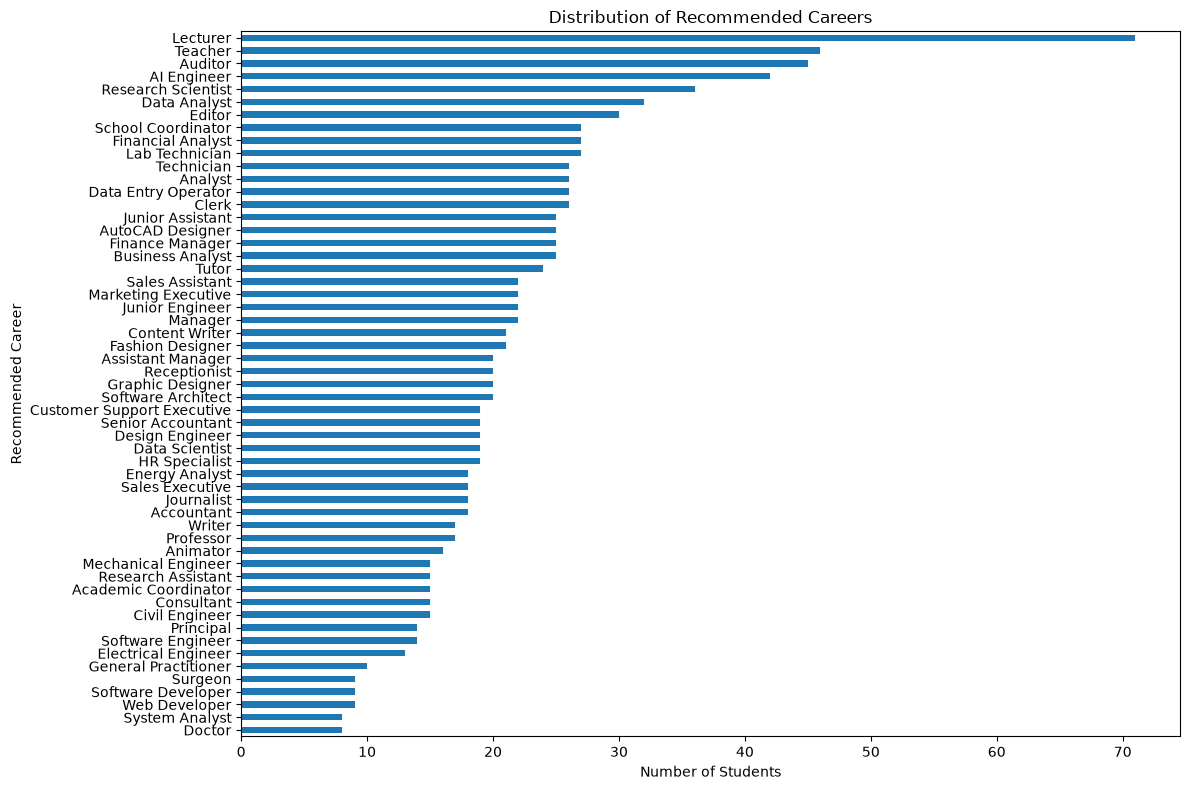

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

career_counts.sort_values(ascending=True).plot(kind="barh")

plt.title("Distribution of Recommended Careers")
plt.xlabel("Number of Students")
plt.ylabel("Recommended Career")
plt.tight_layout()
plt.show()

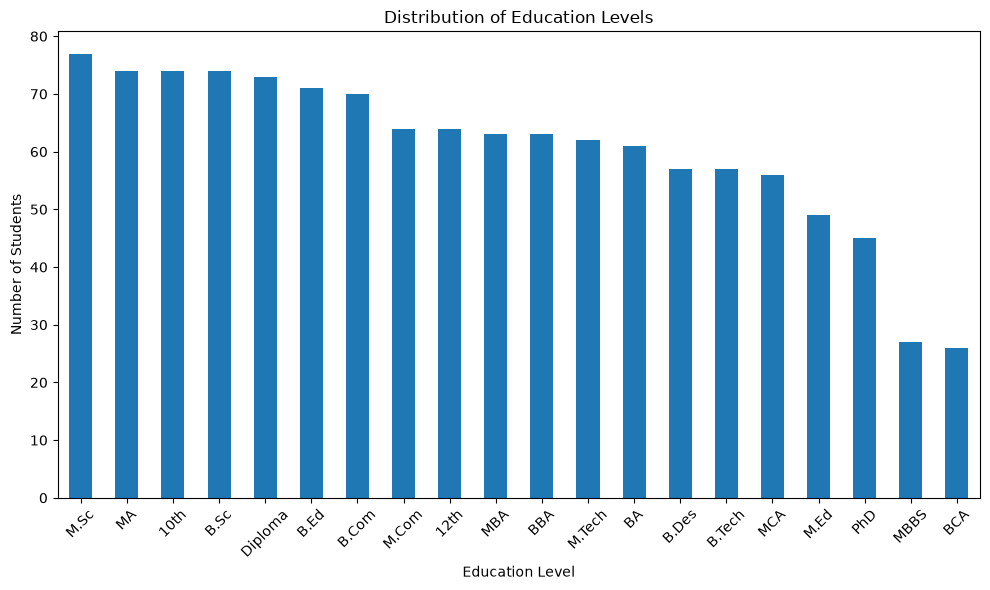

In [10]:
education_counts = df["Education_Level"].value_counts()

plt.figure(figsize=(10, 6))

education_counts.plot(kind="bar")

plt.title("Distribution of Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

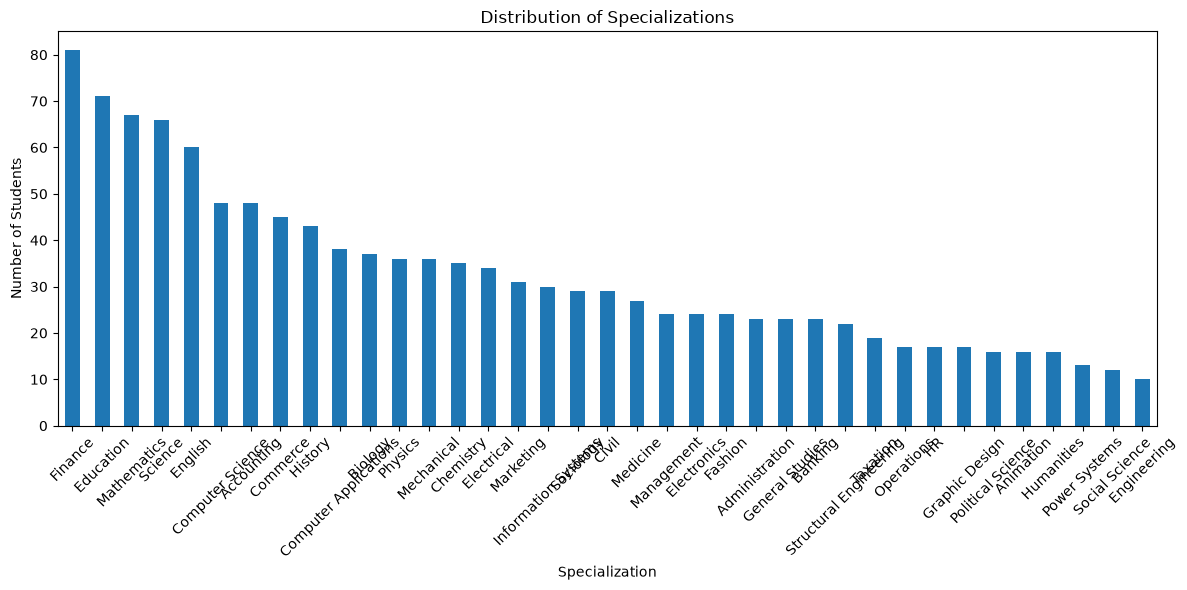

In [11]:
# CELL 11 — Specialization Distribution

specialization_counts = df["Specialization"].value_counts()

plt.figure(figsize=(12, 6))

specialization_counts.plot(kind="bar")

plt.title("Distribution of Specializations")
plt.xlabel("Specialization")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# CELL 12 — Top Skills

skill_count = {}

for skill_list in df["Skills"]:
    for skill in skill_list.split(","):
        skill = skill.strip()

        if skill:
            skill_count[skill] = skill_count.get(skill, 0) + 1

top_skills = pd.Series(skill_count).sort_values(ascending=False).head(10)

print("Top 10 Skills")
display(top_skills)

Top 10 Skills


Communication    198
Research         148
Python           104
Teaching          72
Data Analysis     61
Excel             55
Data Entry        51
AI                47
MATLAB            46
Publication       45
dtype: int64

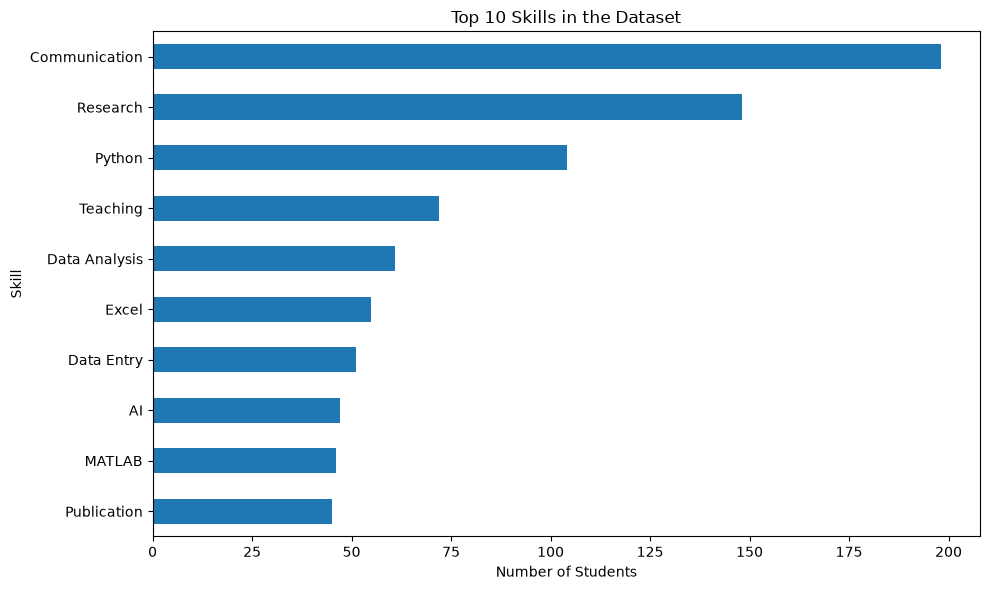

In [13]:
# CELL 13 — Top Skills Chart

plt.figure(figsize=(10, 6))

top_skills.sort_values().plot(kind="barh")

plt.title("Top 10 Skills in the Dataset")
plt.xlabel("Number of Students")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

In [14]:
# CELL 14 — Top Interests

interest_count = {}

for interest_list in df["Interests"]:
    for interest in interest_list.split(","):
        interest = interest.strip()

        if interest:
            interest_count[interest] = interest_count.get(interest, 0) + 1

top_interests = pd.Series(interest_count).sort_values(
    ascending=False
).head(10)

print("Top 10 Interests")
display(top_interests)

Top 10 Interests


Healthcare        131
Technology        128
Teaching          128
Management        127
Creativity        122
Helping People    117
Design            115
Research          114
Business          114
Social Work       111
dtype: int64

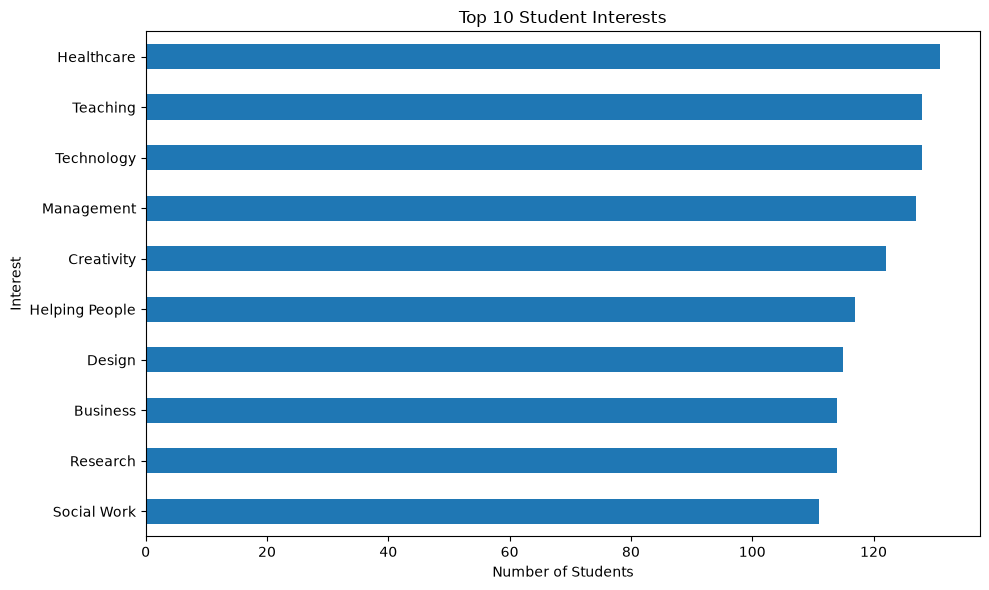

In [15]:
# CELL 15 — Top Interests Chart

plt.figure(figsize=(10, 6))

top_interests.sort_values().plot(kind="barh")

plt.title("Top 10 Student Interests")
plt.xlabel("Number of Students")
plt.ylabel("Interest")

plt.tight_layout()
plt.show()

In [16]:
# CELL 16 — Education vs Career

education_career = pd.crosstab(
    df["Education_Level"],
    df["Recommended_Career"]
)

display(education_career)

Recommended_Career,AI Engineer,Academic Coordinator,Accountant,Analyst,Animator,Assistant Manager,Auditor,AutoCAD Designer,Business Analyst,Civil Engineer,...,Software Architect,Software Developer,Software Engineer,Surgeon,System Analyst,Teacher,Technician,Tutor,Web Developer,Writer
Education_Level,,,,,,,,,,,,,,,,,,,,,
10th,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12th,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B.Com,0,0,18,0,0,0,25,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B.Des,0,0,0,0,16,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B.Ed,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,20,0,24,0,0
B.Sc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B.Tech,0,0,0,0,0,0,0,0,0,15,...,0,0,14,0,0,0,0,0,0,0
BA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,26,0,0,0,17
BBA,0,0,0,0,0,20,0,0,25,0,...,0,0,0,0,0,0,0,0,0,0


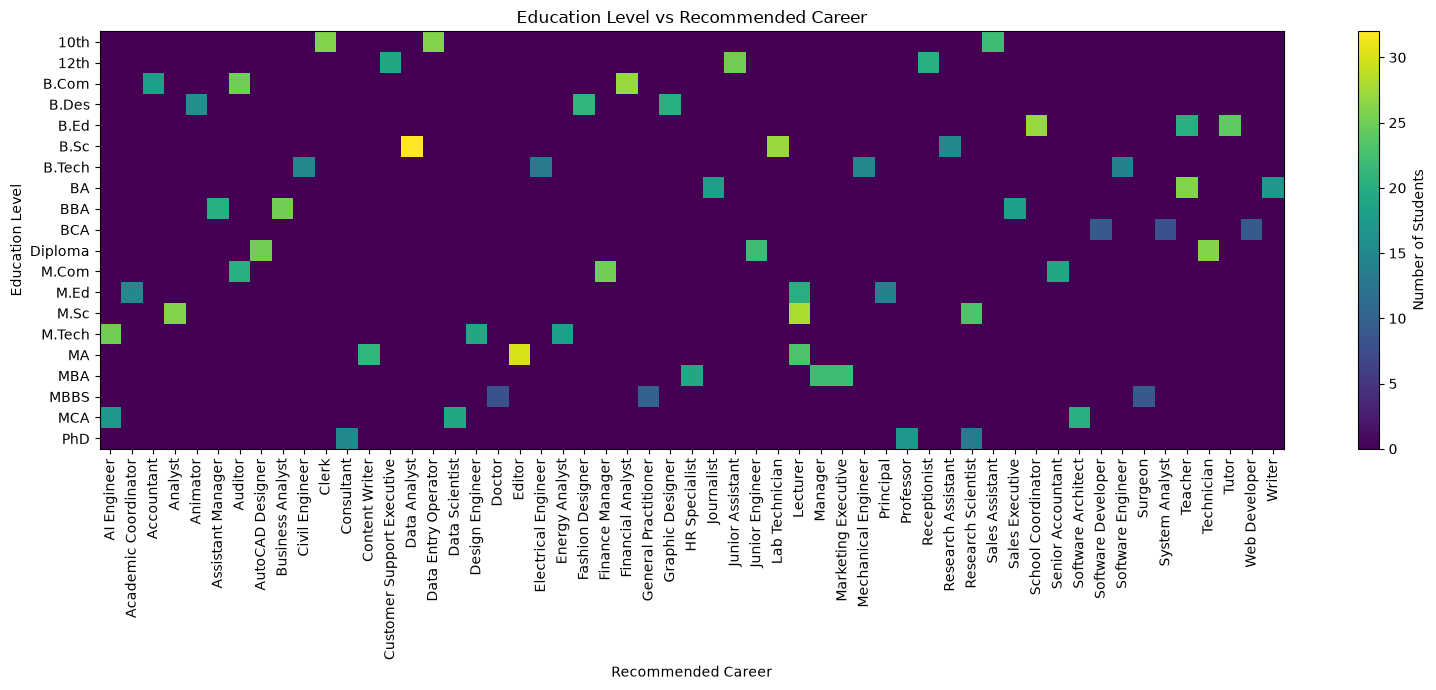

In [17]:
# CELL 17 — Education vs Career Heatmap

plt.figure(figsize=(16, 7))

plt.imshow(education_career, aspect="auto")

plt.colorbar(label="Number of Students")

plt.xticks(
    range(len(education_career.columns)),
    education_career.columns,
    rotation=90
)

plt.yticks(
    range(len(education_career.index)),
    education_career.index
)

plt.title("Education Level vs Recommended Career")
plt.xlabel("Recommended Career")
plt.ylabel("Education Level")

plt.tight_layout()
plt.show()

In [18]:
# CELL 18 — Specialization vs Career

specialization_career = pd.crosstab(
    df["Specialization"],
    df["Recommended_Career"]
)

display(specialization_career)

Recommended_Career,AI Engineer,Academic Coordinator,Accountant,Analyst,Animator,Assistant Manager,Auditor,AutoCAD Designer,Business Analyst,Civil Engineer,...,Software Architect,Software Developer,Software Engineer,Surgeon,System Analyst,Teacher,Technician,Tutor,Web Developer,Writer
Specialization,,,,,,,,,,,,,,,,,,,,,
Accounting,0,0,4,0,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Administration,0,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Animation,0,0,0,0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banking,0,0,6,0,0,0,8,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Biology,0,0,0,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Chemistry,0,0,0,5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Civil,0,0,0,0,0,0,0,9,0,3,...,0,0,0,0,0,0,5,0,0,0
Commerce,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Computer Applications,0,0,0,0,0,0,0,4,0,0,...,0,9,0,0,8,0,4,0,9,0


In [19]:
# CELL 19 — Interests vs Career

interest_career = pd.crosstab(
    df["Interests"],
    df["Recommended_Career"]
)

display(interest_career.head(20))

Recommended_Career,AI Engineer,Academic Coordinator,Accountant,Analyst,Animator,Assistant Manager,Auditor,AutoCAD Designer,Business Analyst,Civil Engineer,...,Software Architect,Software Developer,Software Engineer,Surgeon,System Analyst,Teacher,Technician,Tutor,Web Developer,Writer
Interests,,,,,,,,,,,,,,,,,,,,,
Business,8,1,1,2,1,2,5,1,5,0,...,1,1,2,1,1,5,2,4,1,2
Creativity,5,2,2,3,5,1,4,1,3,4,...,2,0,1,1,0,3,1,3,1,2
Design,3,1,1,3,2,2,4,0,3,1,...,1,1,0,0,1,6,6,2,1,1
Healthcare,3,4,1,3,1,1,8,2,2,0,...,2,1,0,1,1,1,3,3,1,2
Helping People,3,0,0,3,0,3,4,2,3,3,...,2,1,1,1,1,7,1,2,1,4
Management,4,0,2,3,3,2,4,7,4,2,...,3,1,3,1,1,4,4,3,0,1
Research,6,1,4,2,1,2,3,3,2,0,...,3,1,1,1,1,2,3,2,1,2
Social Work,4,1,3,0,0,3,5,2,1,1,...,3,1,2,1,1,5,2,2,1,1
Teaching,4,3,1,5,2,2,2,5,1,2,...,1,1,2,1,0,5,2,2,1,1


In [20]:
# CELL 20 — Career Descriptions

print("Sample Career Descriptions")
print("=" * 50)

display(
    df[
        ["Recommended_Career", "Career_Description"]
    ].drop_duplicates().head(20)
)

Sample Career Descriptions


,Recommended_Career,Career_Description
0,Financial Analyst,B.Com graduates specialized in Finance with sk...
1,HR Specialist,MBA graduates specialized in Marketing with sk...
2,System Analyst,BCA graduates specialized in Computer Applicat...
3,Journalist,BA graduates specialized in Political Science ...
4,System Analyst,BCA graduates specialized in Computer Applicat...
5,Consultant,PhD graduates specialized in Social Science wi...
6,Tutor,B.Ed graduates specialized in Mathematics with...
7,Graphic Designer,B.Des graduates specialized in Animation with ...
8,Teacher,BA graduates specialized in English with skill...
9,Content Writer,MA graduates specialized in History with skill...


In [22]:
# CELL 22 — Import ML Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

print("Machine Learning libraries imported!")

Machine Learning libraries imported!


In [23]:
# CELL 23 — Prepare Features and Target

X = df[
    [
        "Education_Level",
        "Specialization",
        "Skills",
        "Interests"
    ]
]

y = df["Recommended_Career"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print("Recommended_Career")

print("\nInput shape:", X.shape)
print("Target shape:", y.shape)

Input features:
['Education_Level', 'Specialization', 'Skills', 'Interests']

Target:
Recommended_Career

Input shape: (1207, 4)
Target shape: (1207,)


In [24]:
# CELL 24 — Combine Text Features

X = X.copy()

X["Combined_Text"] = (
    X["Specialization"].astype(str) + " " +
    X["Skills"].astype(str) + " " +
    X["Interests"].astype(str)
)

X = X[
    [
        "Education_Level",
        "Combined_Text"
    ]
]

display(X.head())

,Education_Level,Combined_Text
0,B.Com,"Finance Communication, Tax Filing Social Work"
1,MBA,"Marketing Leadership, Strategy, Analytics Mana..."
2,BCA,"Computer Applications Python, Web Development,..."
3,BA,"Political Science Writing, Communication Research"
4,BCA,"Computer Applications Python, Web Development,..."


In [25]:
# CELL 25 — Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 965
Testing samples: 242


In [26]:
# CELL 26 — Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "education",
            OneHotEncoder(handle_unknown="ignore"),
            ["Education_Level"]
        ),
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2
            ),
            "Combined_Text"
        )
    ]
)

print("Preprocessing ready!")

Preprocessing ready!


In [27]:
# CELL 27 — Logistic Regression Model

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced"
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 26.45 %


In [28]:
# CELL 28 — Random Forest Model

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 19.83 %


In [29]:
# CELL 29 — Decision Tree Model

dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=20,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 26.03 %


In [30]:
# CELL 30 — Compare Models

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        dt_accuracy
    ]
})

model_results["Accuracy (%)"] = (
    model_results["Accuracy"] * 100
)

display(
    model_results[
        ["Model", "Accuracy (%)"]
    ].sort_values(
        "Accuracy (%)",
        ascending=False
    )
)

,Model,Accuracy (%)
0,Logistic Regression,26.446281
2,Decision Tree,26.033058
1,Random Forest,19.834711


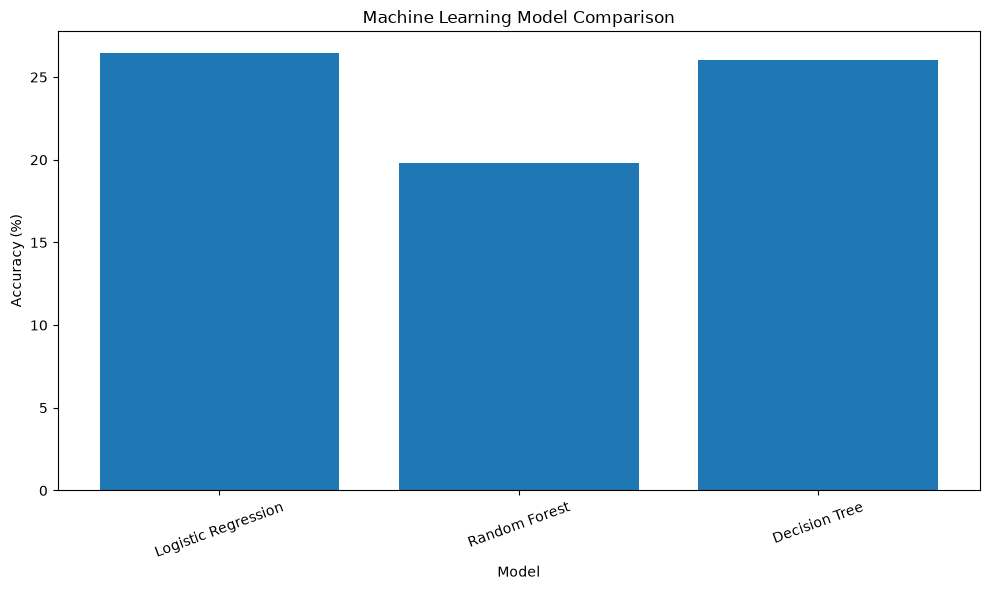

In [31]:
# CELL 31 — Model Comparison Chart

plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Accuracy (%)"]
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [32]:
# CELL 32 — Classification Report

best_model = rf_model
best_pred = rf_pred

print("Classification Report — Random Forest")
print("=" * 60)

print(
    classification_report(
        y_test,
        best_pred,
        zero_division=0
    )
)

Classification Report — Random Forest
                            precision    recall  f1-score   support

               AI Engineer       0.20      0.11      0.14         9
      Academic Coordinator       0.20      0.33      0.25         3
                Accountant       0.40      0.50      0.44         4
                   Analyst       0.10      0.20      0.13         5
                  Animator       0.38      1.00      0.55         3
         Assistant Manager       0.00      0.00      0.00         4
                   Auditor       0.00      0.00      0.00         9
          AutoCAD Designer       0.40      0.40      0.40         5
          Business Analyst       0.00      0.00      0.00         5
            Civil Engineer       0.50      0.33      0.40         3
                     Clerk       0.00      0.00      0.00         5
                Consultant       0.75      1.00      0.86         3
            Content Writer       0.00      0.00      0.00         4
Customer 

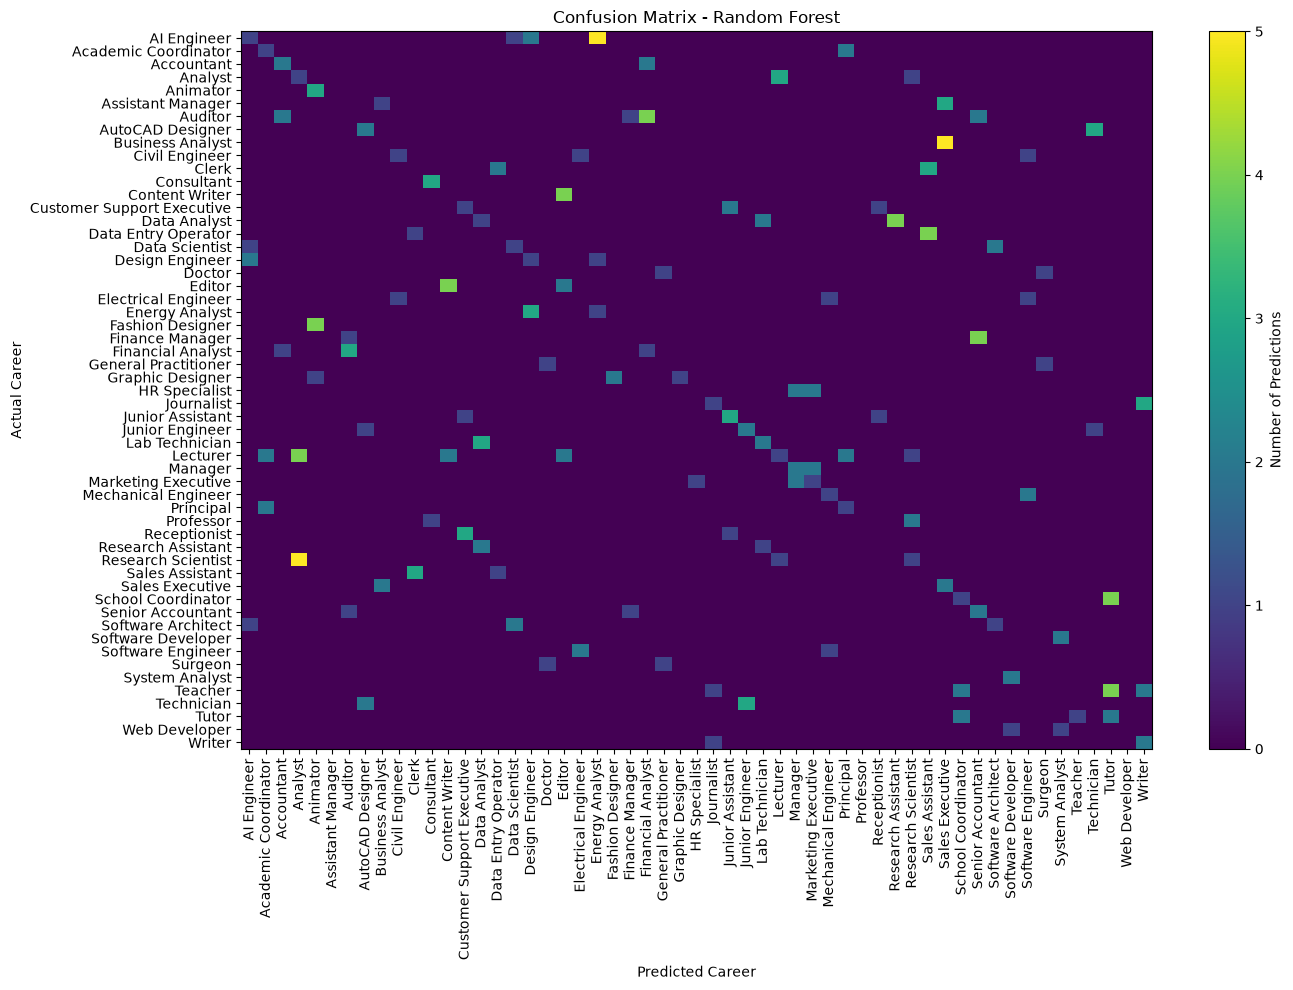

In [33]:
# CELL 33 — Confusion Matrix

labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=labels
)

plt.figure(figsize=(14, 10))

plt.imshow(cm, aspect="auto")

plt.colorbar(label="Number of Predictions")

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Career")
plt.ylabel("Actual Career")

plt.tight_layout()
plt.show()

In [34]:
# CELL 34 — Create a New Student

new_student = pd.DataFrame({
    "Education_Level": ["Bachelor's"],
    "Combined_Text": [
        "Computer Science Python SQL Data Analysis Technology"
    ]
})

display(new_student)

,Education_Level,Combined_Text
0,Bachelor's,Computer Science Python SQL Data Analysis Tech...


In [35]:
# CELL 35 — Predict Career

predicted_career = rf_model.predict(
    new_student
)[0]

print("====================================")
print("       CAREER RECOMMENDATION")
print("====================================")

print("Recommended Career:", predicted_career)

       CAREER RECOMMENDATION
Recommended Career: Research Assistant


In [36]:
# CELL 36 — Prediction Probability

probabilities = rf_model.predict_proba(
    new_student
)[0]

classes = rf_model.classes_

probability_table = pd.DataFrame({
    "Career": classes,
    "Probability (%)": probabilities * 100
})

probability_table = probability_table.sort_values(
    "Probability (%)",
    ascending=False
)

print("Top Career Recommendations")
print("=" * 50)

display(
    probability_table.head(5)
)

Top Career Recommendations


,Career,Probability (%)
39,Research Assistant,11.000000
14,Data Analyst,7.000000
31,Lab Technician,6.333333
11,Consultant,5.961111
16,Data Scientist,5.522222


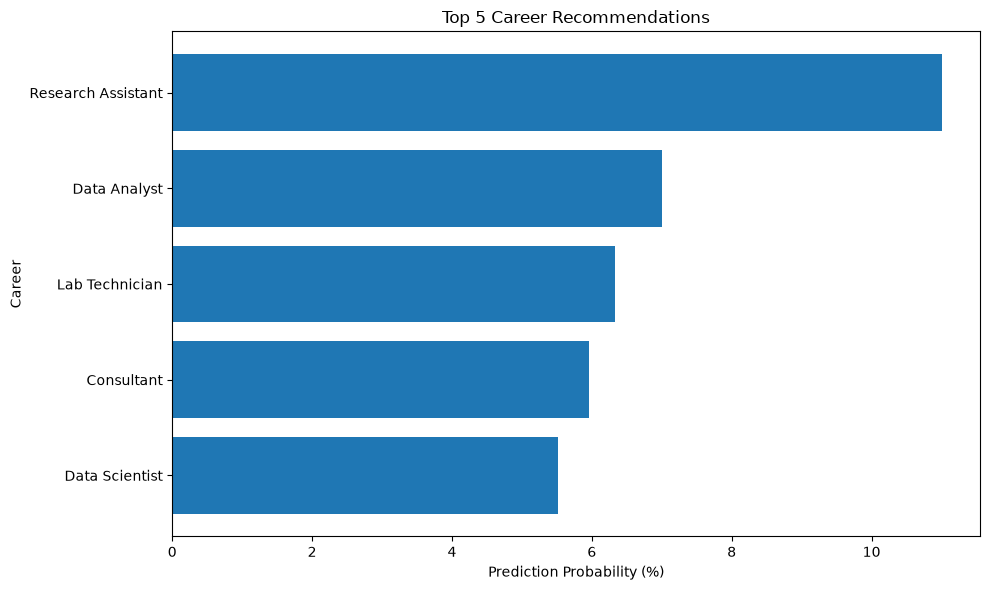

In [37]:
# CELL 37 — Top 5 Career Recommendations Chart

top5 = probability_table.head(5)

plt.figure(figsize=(10, 6))

plt.barh(
    top5["Career"][::-1],
    top5["Probability (%)"][::-1]
)

plt.title("Top 5 Career Recommendations")
plt.xlabel("Prediction Probability (%)")
plt.ylabel("Career")

plt.tight_layout()
plt.show()

In [38]:
# CELL 38 — Final Summary

print("==============================================")
print("       CAREER RECOMMENDATION SYSTEM")
print("==============================================")

print("Original Dataset Size:", 1500)
print("Cleaned Dataset Size:", len(df))
print("Number of Features:", 4)
print("Number of Career Categories:", df["Recommended_Career"].nunique())

print(
    "\nBest Model:",
    model_results.sort_values(
        "Accuracy",
        ascending=False
    ).iloc[0]["Model"]
)

print(
    "Best Accuracy:",
    round(
        model_results["Accuracy (%)"].max(),
        2
    ),
    "%"
)

print("\nRecommended Career for Sample Student:")
print(predicted_career)

       CAREER RECOMMENDATION SYSTEM
Original Dataset Size: 1500
Cleaned Dataset Size: 1207
Number of Features: 4
Number of Career Categories: 55

Best Model: Logistic Regression
Best Accuracy: 26.45 %

Recommended Career for Sample Student:
Research Assistant


In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [40]:
# ------------------------------------------------------------
# 1. Load and clean dataset
# ------------------------------------------------------------

data = pd.read_csv("perfectly_realistic_career_guidance_dataset_1500.csv")

data = data.drop_duplicates().reset_index(drop=True)

print("Final Dataset Shape:", data.shape)

# ------------------------------------------------------------
# 2. Input features and target
# ------------------------------------------------------------

X = data[
    [
        "Education_Level",
        "Specialization",
        "Skills",
        "Interests"
    ]
]

y = data["Recommended_Career"]

# ------------------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 4. Feature Processing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "education",
            OneHotEncoder(handle_unknown="ignore"),
            ["Education_Level"]
        ),
        (
            "specialization",
            OneHotEncoder(handle_unknown="ignore"),
            ["Specialization"]
        ),
        (
            "skills",
            TfidfVectorizer(token_pattern=r"[^,]+"),
            "Skills"
        ),
        (
            "interests",
            TfidfVectorizer(token_pattern=r"[^,]+"),
            "Interests"
        )
    ]
)

# ------------------------------------------------------------
# 5. Logistic Regression Model
# ------------------------------------------------------------

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# 6. Train Model
# ------------------------------------------------------------

final_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 7. Model Accuracy
# ------------------------------------------------------------

y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Logistic Regression Accuracy: {accuracy:.2f}%")

# ------------------------------------------------------------
# 8. New Student Details
# ------------------------------------------------------------

new_student = pd.DataFrame({
    "Education_Level": ["Bachelor's"],
    "Specialization": ["Computer Science"],
    "Skills": ["Python, SQL, Data Analysis, Machine Learning"],
    "Interests": ["Technology, Data, Research"]
})

# ------------------------------------------------------------
# 9. Predict Top Career
# ------------------------------------------------------------

predicted_career = final_model.predict(new_student)[0]

probabilities = final_model.predict_proba(new_student)[0]
classes = final_model.classes_

recommendations = pd.DataFrame({
    "Career": classes,
    "Probability (%)": probabilities * 100
})

recommendations = recommendations.sort_values(
    by="Probability (%)",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 10. Display Final Recommendation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("       AI-BASED CAREER RECOMMENDATION SYSTEM")
print("=" * 60)

print("\nStudent Profile:")
print("Education     :", new_student["Education_Level"].iloc[0])
print("Specialization:", new_student["Specialization"].iloc[0])
print("Skills        :", new_student["Skills"].iloc[0])
print("Interests     :", new_student["Interests"].iloc[0])

print("\n" + "-" * 60)
print("TOP 5 RECOMMENDED CAREERS")
print("-" * 60)

display(recommendations.head(5))

print("\nBEST MATCHED CAREER:")
print(">>>", predicted_career)

print("\n" + "=" * 60)

Final Dataset Shape: (1207, 6)

FINAL MODEL PERFORMANCE
Logistic Regression Accuracy: 28.93%

       AI-BASED CAREER RECOMMENDATION SYSTEM

Student Profile:
Education     : Bachelor's
Specialization: Computer Science
Skills        : Python, SQL, Data Analysis, Machine Learning
Interests     : Technology, Data, Research

------------------------------------------------------------
TOP 5 RECOMMENDED CAREERS
------------------------------------------------------------


,Career,Probability (%)
0,Software Architect,6.512493
1,Software Engineer,5.528399
2,AI Engineer,5.061837
3,Teacher,4.240561
4,Mechanical Engineer,4.195317



BEST MATCHED CAREER:
>>> Software Architect



In [41]:
# ============================================================
# STEP 6 - USER INPUT CAREER RECOMMENDATION SYSTEM
# ============================================================

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("perfectly_realistic_career_guidance_dataset_1500.csv")

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# ------------------------------------------------------------
# Load the trained model and preprocessing from Step 5
# ------------------------------------------------------------
# If your Step 5 variables are still available, use them directly.

print("=" * 65)
print("       AI-BASED CAREER RECOMMENDATION SYSTEM")
print("=" * 65)

print("\nEnter Student Details\n")

# User inputs
education = input("Enter Education Level: ")
specialization = input("Enter Specialization: ")
skills = input("Enter Skills (comma separated): ")
interests = input("Enter Interests (comma separated): ")

# ------------------------------------------------------------
# Create input DataFrame
# ------------------------------------------------------------

student = pd.DataFrame({
    "Education_Level": [education],
    "Specialization": [specialization],
    "Skills": [skills],
    "Interests": [interests]
})

# ------------------------------------------------------------
# Prediction using the Logistic Regression model
# ------------------------------------------------------------

probabilities = final_model.predict_proba(student)[0]
careers = final_model.classes_

# Get Top 5 careers
top_indices = np.argsort(probabilities)[::-1][:5]

top_careers = pd.DataFrame({
    "Career": careers[top_indices],
    "Probability (%)": probabilities[top_indices] * 100
})

top_careers["Probability (%)"] = top_careers["Probability (%)"].round(2)

# ------------------------------------------------------------
# Display Student Profile
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("                  STUDENT PROFILE")
print("=" * 65)

print("Education      :", education)
print("Specialization :", specialization)
print("Skills         :", skills)
print("Interests      :", interests)

# ------------------------------------------------------------
# Display Recommendations
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("              TOP 5 RECOMMENDED CAREERS")
print("=" * 65)

display(top_careers)

# ------------------------------------------------------------
# Best Career
# ------------------------------------------------------------

best_career = careers[top_indices[0]]

print("\n" + "=" * 65)
print("BEST MATCHED CAREER")
print("=" * 65)

print(">>>", best_career)

print("\nCareer recommendation completed successfully! ✅")

       AI-BASED CAREER RECOMMENDATION SYSTEM

Enter Student Details



Enter Education Level:  Bachelor's
Enter Specialization:  Computer Science
Enter Skills (comma separated):  Python, SQL, Data Analysis, Machine Learning
Enter Interests (comma separated):  Technology, Data, Research



                  STUDENT PROFILE
Education      : Bachelor's
Specialization : Computer Science
Skills         : Python, SQL, Data Analysis, Machine Learning
Interests      : Technology, Data, Research

              TOP 5 RECOMMENDED CAREERS


,Career,Probability (%)
0,Software Architect,6.51
1,Software Engineer,5.53
2,AI Engineer,5.06
3,Teacher,4.24
4,Mechanical Engineer,4.20



BEST MATCHED CAREER
>>> Software Architect

Career recommendation completed successfully! ✅


In [4]:
# ============================================================
# STEP 7 - INTERACTIVE AI CAREER RECOMMENDATION SYSTEM
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import ipywidgets as widgets
from IPython.display import display, clear_output


# ============================================================
# 1. LOAD AND CLEAN DATASET
# ============================================================

df_ui = pd.read_csv(
    "perfectly_realistic_career_guidance_dataset_1500.csv"
)

df_ui = df_ui.drop_duplicates().reset_index(drop=True)

print("Dataset loaded successfully!")
print("Final Dataset Shape:", df_ui.shape)


# ============================================================
# 2. PREPARE DATA
# ============================================================

X = df_ui[
    [
        "Education_Level",
        "Specialization",
        "Skills",
        "Interests"
    ]
]

y = df_ui["Recommended_Career"]


# ============================================================
# 3. TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "education",
            OneHotEncoder(handle_unknown="ignore"),
            ["Education_Level"]
        ),
        (
            "specialization",
            OneHotEncoder(handle_unknown="ignore"),
            ["Specialization"]
        ),
        (
            "skills",
            TfidfVectorizer(
                token_pattern=r"[^,]+"
            ),
            "Skills"
        ),
        (
            "interests",
            TfidfVectorizer(
                token_pattern=r"[^,]+"
            ),
            "Interests"
        )
    ]
)


# Create model
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]
)


# Train the model
final_model.fit(X, y)

print("Model trained successfully! ✅")


# ============================================================
# 4. CREATE USER INPUT WIDGETS
# ============================================================

education_dropdown = widgets.Dropdown(
    options=sorted(df_ui["Education_Level"].unique()),
    description="Education:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)


specialization_dropdown = widgets.Dropdown(
    options=sorted(df_ui["Specialization"].unique()),
    description="Specialization:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)


skills_input = widgets.Text(
    value="Python, SQL, Data Analysis, Machine Learning",
    description="Skills:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="750px")
)


interests_input = widgets.Text(
    value="Technology, Data, Research",
    description="Interests:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="750px")
)


recommend_button = widgets.Button(
    description="🔍 Recommend Career",
    button_style="success",
    layout=widgets.Layout(
        width="250px",
        height="45px"
    )
)


output = widgets.Output()


# ============================================================
# 5. RECOMMENDATION FUNCTION
# ============================================================

def recommend_career(button):

    with output:

        clear_output()

        # Create student profile
        student = pd.DataFrame({
            "Education_Level": [
                education_dropdown.value
            ],
            "Specialization": [
                specialization_dropdown.value
            ],
            "Skills": [
                skills_input.value
            ],
            "Interests": [
                interests_input.value
            ]
        })


        # Get prediction probabilities
        probabilities = final_model.predict_proba(student)[0]

        careers = final_model.classes_


        # Get Top 5 careers
        top_indices = np.argsort(
            probabilities
        )[::-1][:5]


        top_careers = pd.DataFrame({
            "Career": careers[top_indices],
            "Probability (%)":
                probabilities[top_indices] * 100
        })


        top_careers["Probability (%)"] = (
            top_careers["Probability (%)"].round(2)
        )


        # Best career
        best_career = careers[top_indices[0]]


        # ====================================================
        # DISPLAY RESULT
        # ====================================================

        print("=" * 70)
        print("       🤖 AI-BASED CAREER RECOMMENDATION SYSTEM")
        print("=" * 70)


        print("\nSTUDENT PROFILE")
        print("-" * 70)

        print(
            "Education      :",
            education_dropdown.value
        )

        print(
            "Specialization :",
            specialization_dropdown.value
        )

        print(
            "Skills         :",
            skills_input.value
        )

        print(
            "Interests      :",
            interests_input.value
        )


        print("\n" + "=" * 70)
        print("             TOP 5 RECOMMENDED CAREERS")
        print("=" * 70)

        display(top_careers)


        print("\n" + "=" * 70)
        print("                 🏆 BEST MATCHED CAREER")
        print("=" * 70)

        print("\n>>>", best_career)

        print("\n" + "=" * 70)
        print("Career recommendation generated successfully! ✅")
        print("=" * 70)


# Connect button
recommend_button.on_click(recommend_career)


# ============================================================
# 6. DISPLAY INTERACTIVE INTERFACE
# ============================================================

display(
    widgets.HTML(
        """
        <h2>🎓 AI Career Recommendation System</h2>
        <p>
        Enter your education, specialization, skills and interests
        to get career recommendations.
        </p>
        """
    )
)

display(education_dropdown)
display(specialization_dropdown)
display(skills_input)
display(interests_input)

display(recommend_button)

display(output)

Dataset loaded successfully!
Final Dataset Shape: (1207, 6)
Model trained successfully! ✅


HTML(value='\n        <h2>🎓 AI Career Recommendation System</h2>\n        <p>\n        Enter your education, s…

Dropdown(description='Education:', layout=Layout(width='500px'), options=('10th', '12th', 'B.Com', 'B.Des', 'B…

Dropdown(description='Specialization:', layout=Layout(width='500px'), options=('Accounting', 'Administration',…

Text(value='Python, SQL, Data Analysis, Machine Learning', description='Skills:', layout=Layout(width='750px')…

Text(value='Technology, Data, Research', description='Interests:', layout=Layout(width='750px'), style=TextSty…

Button(button_style='success', description='🔍 Recommend Career', layout=Layout(height='45px', width='250px'), …

Output()

        TOP 5 CAREER PROBABILITY VISUALIZATION
1. Data Analyst : 24.49%
2. Lab Technician : 14.73%
3. Research Assistant : 14.58%
4. Software Architect : 2.83%
5. Software Engineer : 2.80%


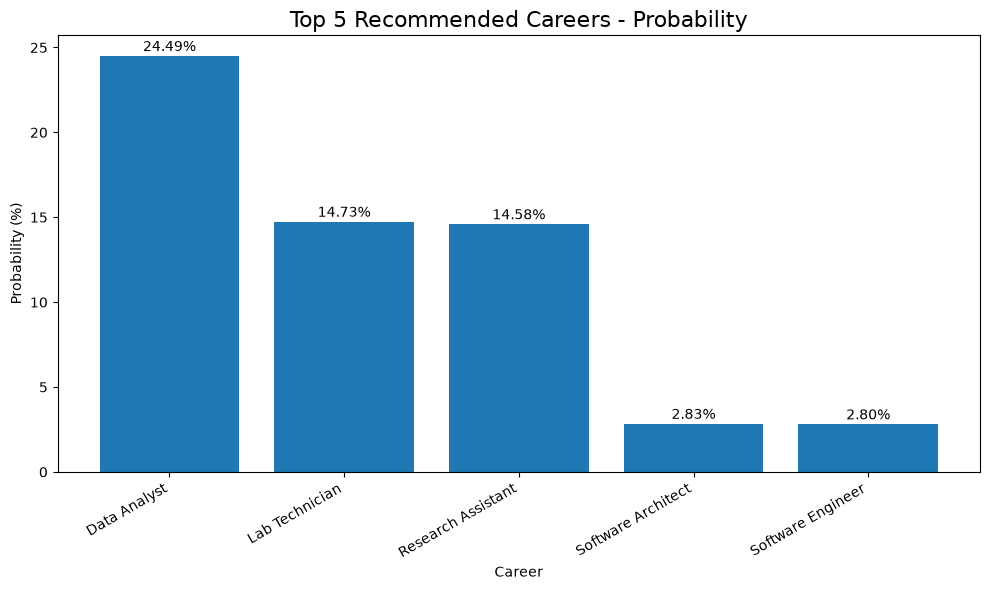


🏆 BEST MATCHED CAREER:
>>> Data Analyst


In [5]:
# ============================================================
# STEP 8 - TOP 5 CAREER PROBABILITY VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. GET CURRENT STUDENT INPUT
# ------------------------------------------------------------

student_graph = pd.DataFrame({
    "Education_Level": [education_dropdown.value],
    "Specialization": [specialization_dropdown.value],
    "Skills": [skills_input.value],
    "Interests": [interests_input.value]
})

# ------------------------------------------------------------
# 2. PREDICT CAREER PROBABILITIES
# ------------------------------------------------------------

probabilities = final_model.predict_proba(student_graph)[0]
careers = final_model.classes_

# Get Top 5
top_indices = np.argsort(probabilities)[::-1][:5]

top_5_careers = careers[top_indices]
top_5_probabilities = probabilities[top_indices] * 100

# ------------------------------------------------------------
# 3. DISPLAY TOP 5 RESULTS
# ------------------------------------------------------------

print("=" * 65)
print("        TOP 5 CAREER PROBABILITY VISUALIZATION")
print("=" * 65)

for i in range(5):
    print(
        f"{i+1}. {top_5_careers[i]} : "
        f"{top_5_probabilities[i]:.2f}%"
    )

# ------------------------------------------------------------
# 4. CREATE BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_5_careers,
    top_5_probabilities
)

plt.title(
    "Top 5 Recommended Careers - Probability",
    fontsize=16
)

plt.xlabel("Career")
plt.ylabel("Probability (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

# Add percentage values on top of bars
for bar, value in zip(bars, top_5_probabilities):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. BEST CAREER
# ------------------------------------------------------------

print("\n🏆 BEST MATCHED CAREER:")
print(">>>", top_5_careers[0])

In [7]:
# STEP 9 - MODEL PERFORMANCE COMPARISON

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Load dataset
df_model = pd.read_csv(
    "perfectly_realistic_career_guidance_dataset_1500.csv"
)

# Remove duplicates
df_model = df_model.drop_duplicates().reset_index(drop=True)

print("Dataset Shape:", df_model.shape)


# Input features
X = df_model[
    ["Education_Level", "Specialization", "Skills", "Interests"]
]

# Target
y = df_model["Recommended_Career"]


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "education",
            OneHotEncoder(handle_unknown="ignore"),
            ["Education_Level"]
        ),
        (
            "specialization",
            OneHotEncoder(handle_unknown="ignore"),
            ["Specialization"]
        ),
        (
            "skills",
            TfidfVectorizer(token_pattern=r"[^,]+"),
            "Skills"
        ),
        (
            "interests",
            TfidfVectorizer(token_pattern=r"[^,]+"),
            "Interests"
        )
    ]
)


# Logistic Regression
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000))
    ]
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred) * 100

print("Logistic Regression Accuracy:",
      round(lr_accuracy, 2), "%")


# Decision Tree
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred) * 100

print("Decision Tree Accuracy:",
      round(dt_accuracy, 2), "%")


# Random Forest
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred) * 100

print("Random Forest Accuracy:",
      round(rf_accuracy, 2), "%")

Dataset Shape: (1207, 6)
Logistic Regression Accuracy: 28.93 %
Decision Tree Accuracy: 19.83 %
Random Forest Accuracy: 19.42 %


MODEL PERFORMANCE COMPARISON


,Model,Accuracy (%)
0,Logistic Regression,28.93
1,Decision Tree,19.83
2,Random Forest,19.42



BEST PERFORMING MODEL:
Logistic Regression - 28.93 %


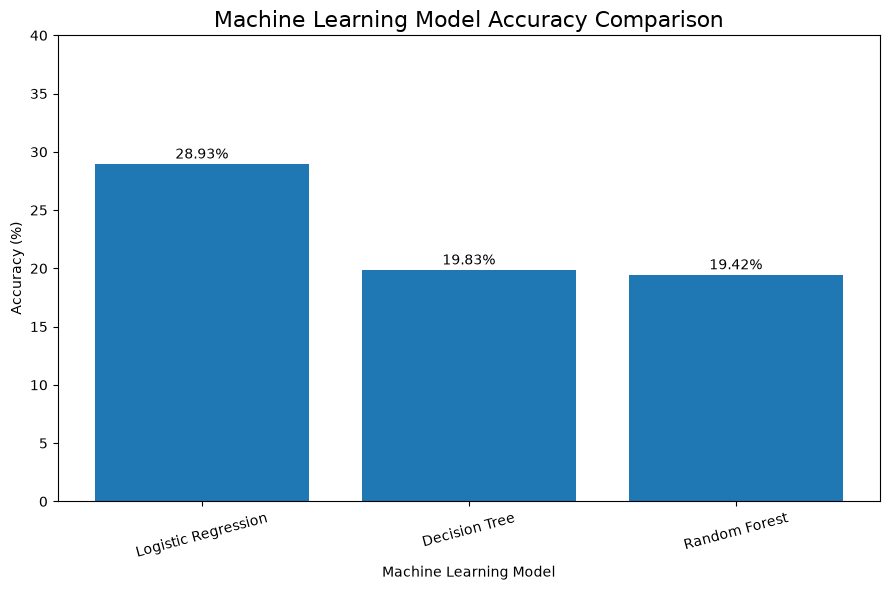

In [8]:
# STEP 9 - MODEL ACCURACY COMPARISON GRAPH

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy
]

# Create table
results = pd.DataFrame({
    "Model": models,
    "Accuracy (%)": accuracies
})

results["Accuracy (%)"] = results["Accuracy (%)"].round(2)

print("MODEL PERFORMANCE COMPARISON")
display(results)

# Best model
best_index = results["Accuracy (%)"].idxmax()
best_model = results.loc[best_index, "Model"]
best_accuracy = results.loc[best_index, "Accuracy (%)"]

print("\nBEST PERFORMING MODEL:")
print(best_model, "-", best_accuracy, "%")

# Bar chart
plt.figure(figsize=(9, 6))

bars = plt.bar(models, accuracies)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=16
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 40)

# Add accuracy values
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

       LOGISTIC REGRESSION - CLASSIFICATION REPORT
                            precision    recall  f1-score   support

               AI Engineer       0.50      0.56      0.53         9
      Academic Coordinator       0.00      0.00      0.00         3
                Accountant       0.33      0.25      0.29         4
                   Analyst       0.33      0.40      0.36         5
                  Animator       0.29      0.67      0.40         3
         Assistant Manager       0.25      0.25      0.25         4
                   Auditor       0.17      0.11      0.13         9
          AutoCAD Designer       0.50      0.20      0.29         5
          Business Analyst       0.40      0.40      0.40         5
            Civil Engineer       0.40      0.67      0.50         3
                     Clerk       0.25      0.20      0.22         5
                Consultant       0.00      0.00      0.00         3
            Content Writer       0.17      0.25      0.20       

<Figure size 1400x1200 with 0 Axes>

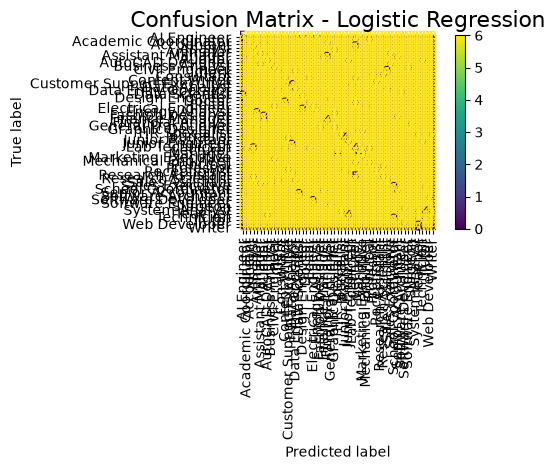

FINAL MODEL EVALUATION
Model              : Logistic Regression
Test Accuracy      : 28.93 %
Number of Classes  : 55

Evaluation completed successfully! ✅


In [9]:
# ============================================================
# STEP 10 - CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ------------------------------------------------------------
# 1. USE LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

# Predictions on test data
lr_predictions = lr_model.predict(X_test)


# ------------------------------------------------------------
# 2. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("=" * 70)
print("       LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        lr_predictions,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 3. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=lr_model.classes_
)


# ------------------------------------------------------------
# 4. DISPLAY CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. FINAL EVALUATION
# ------------------------------------------------------------

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print("Model              : Logistic Regression")
print("Test Accuracy      :", round(lr_accuracy, 2), "%")
print("Number of Classes  :", len(lr_model.classes_))

print("\nEvaluation completed successfully! ✅")

TOP 10 MOST COMMON SKILLS


,Skill,Frequency
0,Communication,198
1,Research,148
2,Python,104
3,Teaching,72
4,Data Analysis,61
5,Excel,55
6,Data Entry,51
7,AI,47
8,MATLAB,46
9,Publication,45


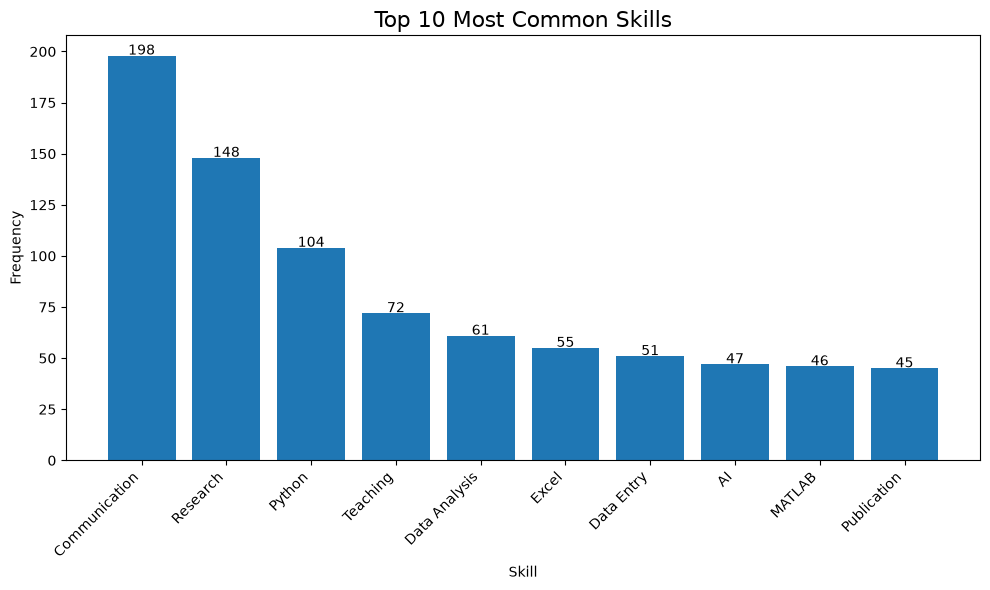


Skill analysis completed successfully! ✅


In [10]:
# ============================================================
# STEP 11 - TOP SKILLS ANALYSIS
# ============================================================

from collections import Counter
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. COLLECT ALL SKILLS
# ------------------------------------------------------------

all_skills = []

for skill_text in df_model["Skills"].dropna():

    skills = skill_text.split(",")

    for skill in skills:
        skill = skill.strip()

        if skill != "":
            all_skills.append(skill)


# ------------------------------------------------------------
# 2. COUNT SKILLS
# ------------------------------------------------------------

skill_counts = Counter(all_skills)

top_skills = skill_counts.most_common(10)


# ------------------------------------------------------------
# 3. CREATE DATAFRAME
# ------------------------------------------------------------

skills_df = pd.DataFrame(
    top_skills,
    columns=["Skill", "Frequency"]
)

print("=" * 60)
print("TOP 10 MOST COMMON SKILLS")
print("=" * 60)

display(skills_df)


# ------------------------------------------------------------
# 4. CREATE BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

bars = plt.bar(
    skills_df["Skill"],
    skills_df["Frequency"]
)

plt.title(
    "Top 10 Most Common Skills",
    fontsize=16
)

plt.xlabel("Skill")
plt.ylabel("Frequency")

plt.xticks(
    rotation=45,
    ha="right"
)


# Add values
for bar, value in zip(
    bars,
    skills_df["Frequency"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()


print("\nSkill analysis completed successfully! ✅")

TOP 10 MOST COMMON INTERESTS


,Interest,Frequency
0,Healthcare,131
1,Technology,128
2,Teaching,128
3,Management,127
4,Creativity,122
5,Helping People,117
6,Design,115
7,Research,114
8,Business,114
9,Social Work,111


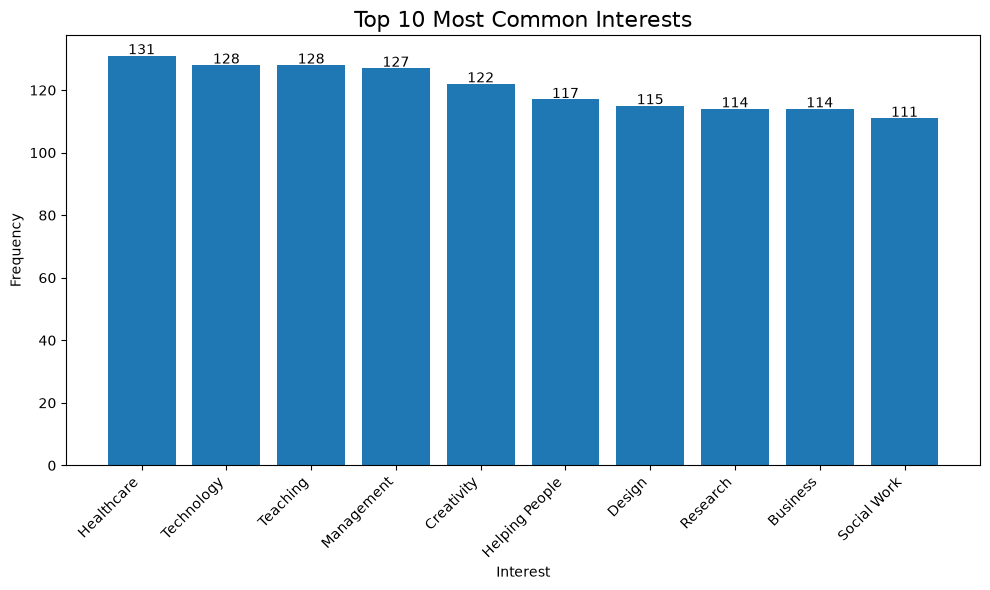


Interest analysis completed successfully! ✅


In [11]:
# ============================================================
# STEP 12 - TOP INTERESTS ANALYSIS
# ============================================================

from collections import Counter
import matplotlib.pyplot as plt

# Collect all interests
all_interests = []

for interest_text in df_model["Interests"].dropna():

    interests = interest_text.split(",")

    for interest in interests:
        interest = interest.strip()

        if interest != "":
            all_interests.append(interest)


# Count interests
interest_counts = Counter(all_interests)

top_interests = interest_counts.most_common(10)


# Create DataFrame
interests_df = pd.DataFrame(
    top_interests,
    columns=["Interest", "Frequency"]
)

print("=" * 60)
print("TOP 10 MOST COMMON INTERESTS")
print("=" * 60)

display(interests_df)


# Create chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    interests_df["Interest"],
    interests_df["Frequency"]
)

plt.title(
    "Top 10 Most Common Interests",
    fontsize=16
)

plt.xlabel("Interest")
plt.ylabel("Frequency")

plt.xticks(
    rotation=45,
    ha="right"
)


# Add values
for bar, value in zip(
    bars,
    interests_df["Frequency"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

print("\nInterest analysis completed successfully! ✅")

In [13]:
# ============================================================
# STEP 13 - FINAL PROJECT SUMMARY
# ============================================================

# Student details
student_education = "B.Sc"
student_specialization = "Computer Science"
student_skills = "Python, SQL, Data Analysis, Machine Learning"
student_interests = "Technology, Data, Research"


# Create student profile
student_data = pd.DataFrame({
    "Education_Level": [student_education],
    "Specialization": [student_specialization],
    "Skills": [student_skills],
    "Interests": [student_interests]
})


# Get career probabilities
student_probabilities = lr_model.predict_proba(student_data)[0]

career_names = lr_model.classes_

# Create recommendation table
recommendation_df = pd.DataFrame({
    "Career": career_names,
    "Probability (%)": student_probabilities * 100
})

# Sort from highest to lowest
recommendation_df = recommendation_df.sort_values(
    by="Probability (%)",
    ascending=False
).reset_index(drop=True)

# Top 5 careers
top5_final = recommendation_df.head(5)

# Best career
best_career_final = top5_final.iloc[0]["Career"]


# ============================================================
# DISPLAY FINAL SUMMARY
# ============================================================

print("=" * 70)
print("          AI-BASED CAREER RECOMMENDATION SYSTEM")
print("=" * 70)

print("\nFINAL PROJECT SUMMARY")
print("-" * 70)

print("Dataset Shape        :", df_model.shape)
print("Total Students       :", len(df_model))
print(
    "Total Career Classes :",
    df_model["Recommended_Career"].nunique()
)


print("\nBEST MACHINE LEARNING MODEL")
print("-" * 70)

print("Model                : Logistic Regression")
print("Accuracy             :", round(lr_accuracy, 2), "%")


print("\nSTUDENT PROFILE")
print("-" * 70)

print("Education            :", student_education)
print("Specialization       :", student_specialization)
print("Skills               :", student_skills)
print("Interests            :", student_interests)


print("\nTOP 5 RECOMMENDED CAREERS")
print("-" * 70)

for i, row in top5_final.iterrows():

    print(
        f"{i + 1}. {row['Career']:<25}"
        f"{row['Probability (%)']:.2f}%"
    )


print("\n" + "=" * 70)
print("BEST MATCHED CAREER")
print("=" * 70)

print(">>>", best_career_final)

print("\n" + "=" * 70)
print("CAREER RECOMMENDATION COMPLETED SUCCESSFULLY! ✅")
print("=" * 70)

          AI-BASED CAREER RECOMMENDATION SYSTEM

FINAL PROJECT SUMMARY
----------------------------------------------------------------------
Dataset Shape        : (1207, 6)
Total Students       : 1207
Total Career Classes : 55

BEST MACHINE LEARNING MODEL
----------------------------------------------------------------------
Model                : Logistic Regression
Accuracy             : 28.93 %

STUDENT PROFILE
----------------------------------------------------------------------
Education            : B.Sc
Specialization       : Computer Science
Skills               : Python, SQL, Data Analysis, Machine Learning
Interests            : Technology, Data, Research

TOP 5 RECOMMENDED CAREERS
----------------------------------------------------------------------
1. Data Analyst             21.68%
2. Research Assistant       14.56%
3. Lab Technician           14.53%
4. Software Architect       3.53%
5. Software Engineer        2.98%

BEST MATCHED CAREER
>>> Data Analyst

CAREER RECOMM

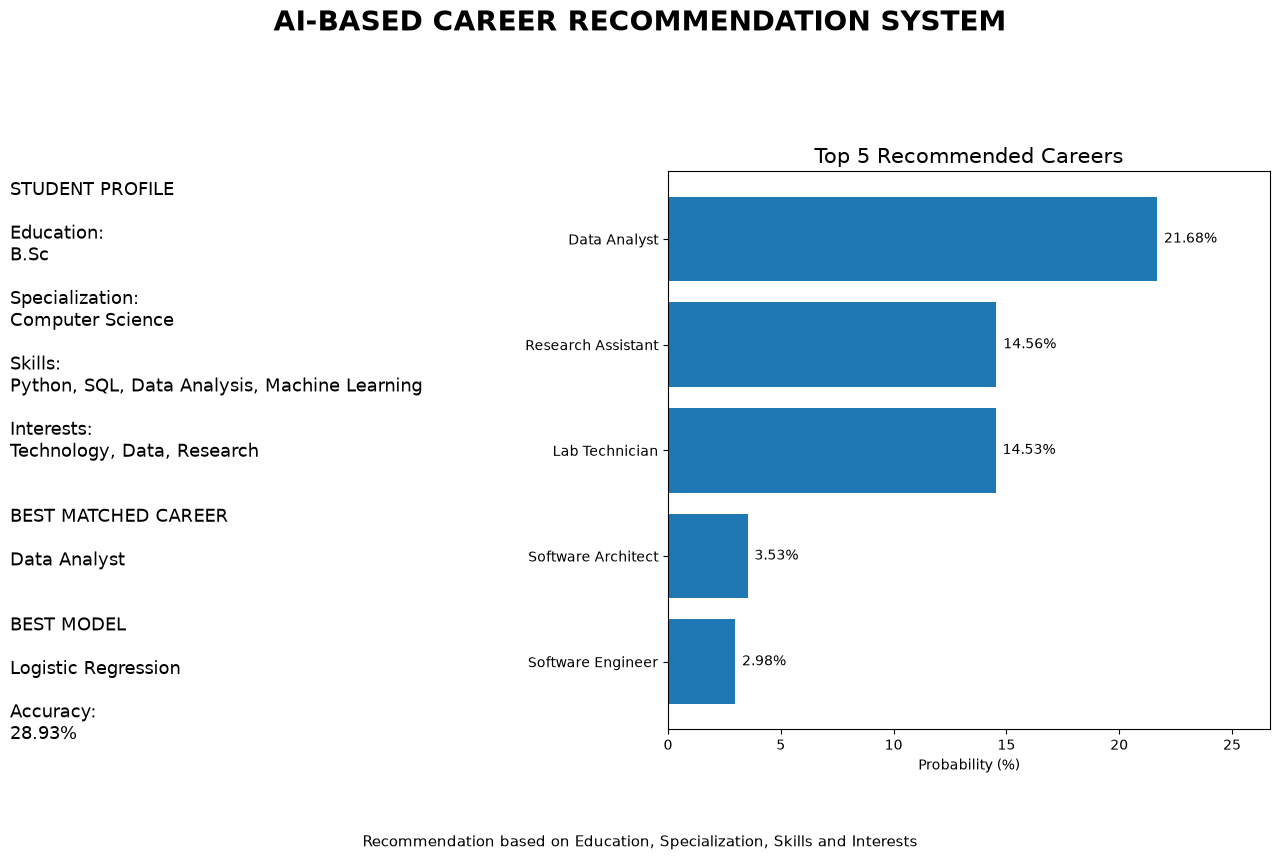


Final dashboard generated successfully! ✅


In [14]:
# ============================================================
# STEP 14 - FINAL CAREER RECOMMENDATION DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# Get top 5 recommendations
dashboard_data = top5_final.copy()

# ------------------------------------------------------------
# CREATE DASHBOARD
# ------------------------------------------------------------

fig = plt.figure(figsize=(14, 9))

# Title
fig.suptitle(
    "AI-BASED CAREER RECOMMENDATION SYSTEM",
    fontsize=20,
    fontweight="bold"
)

# ------------------------------------------------------------
# LEFT SIDE - STUDENT PROFILE
# ------------------------------------------------------------

ax1 = fig.add_axes([0.05, 0.15, 0.40, 0.70])
ax1.axis("off")

profile_text = f"""
STUDENT PROFILE

Education:
{student_education}

Specialization:
{student_specialization}

Skills:
{student_skills}

Interests:
{student_interests}


BEST MATCHED CAREER

{best_career_final}


BEST MODEL

Logistic Regression

Accuracy:
{lr_accuracy:.2f}%
"""

ax1.text(
    0,
    0.95,
    profile_text,
    fontsize=13,
    verticalalignment="top"
)


# ------------------------------------------------------------
# RIGHT SIDE - TOP 5 CAREERS
# ------------------------------------------------------------

ax2 = fig.add_axes([0.52, 0.18, 0.43, 0.62])

bars = ax2.barh(
    dashboard_data["Career"][::-1],
    dashboard_data["Probability (%)"][::-1]
)

ax2.set_title(
    "Top 5 Recommended Careers",
    fontsize=15
)

ax2.set_xlabel("Probability (%)")

# Add percentage values
for bar in bars:

    width = bar.get_width()

    ax2.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center"
    )

ax2.set_xlim(
    0,
    dashboard_data["Probability (%)"].max() + 5
)

# ------------------------------------------------------------
# FOOTER
# ------------------------------------------------------------

fig.text(
    0.5,
    0.05,
    "Recommendation based on Education, Specialization, Skills and Interests",
    ha="center",
    fontsize=11
)

plt.show()

print("\nFinal dashboard generated successfully! ✅")